# Apache Kafka — Complete Reference

> **Ref**: [hellointerview.com — Kafka Deep Dive](https://www.hellointerview.com/learn/system-design/deep-dives/kafka)  

---

## Table of Contents
1. [What is Kafka?](#1-what-is-kafka)
2. [Core Architecture](#2-core-architecture)
3. [Producers](#3-producers)
4. [Consumers & Consumer Groups](#4-consumers--consumer-groups)
5. [Offsets & Delivery Guarantees](#5-offsets--delivery-guarantees)
6. [Replication & Fault Tolerance](#6-replication--fault-tolerance)
7. [Retention & Log Compaction](#7-retention--log-compaction)
8. [Ordering Guarantees](#8-ordering-guarantees)
9. [Kafka as Queue vs. Kafka as Stream](#9-kafka-as-queue-vs-kafka-as-stream)
10. [Scaling Kafka](#10-scaling-kafka)
11. [Common Deep Dives](#11-common-deep-dives)
12. [When to Use Kafka](#12-when-to-use-kafka)
13. [Key Interview Talking Points](#13-key-interview-talking-points)

---

## 1. What is Kafka?

Kafka is an **open-source distributed event streaming platform** that acts as a high-throughput, durable, ordered message log. It solves the problem of moving large volumes of data between services reliably and in real time.

**Core problem it solves**: A single server cannot ingest and process millions of events per second. Kafka distributes this across a cluster — partitioned, replicated, and fault-tolerant.

```
Without Kafka (tight coupling):
  Service A ──► Service B
  Service A ──► Service C       ← each connection is brittle; A must know about B, C, D
  Service A ──► Service D

With Kafka (decoupled):
  Service A ──► [Kafka Topic] ──► Service B
                              ──► Service C    ← A just writes; consumers are independent
                              ──► Service D
```

**Two modes Kafka operates in**:
- **Message Queue mode** — each message processed by one consumer (competing consumers within a group)
- **Event Stream mode** — log retained; multiple consumer groups independently replay the same data

---

## 2. Core Architecture

### 2.1 The Big Picture

```
┌──────────────────────────────────────────────────────────────────────┐
│                           Kafka Cluster                              │
│                                                                      │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐          │
│  │   Broker 1   │    │   Broker 2   │    │   Broker 3   │          │
│  │              │    │              │    │              │          │
│  │ P0 (leader)  │    │ P1 (leader)  │    │ P2 (leader)  │          │
│  │ P1 (replica) │    │ P2 (replica) │    │ P0 (replica) │          │
│  │ P2 (replica) │    │ P0 (replica) │    │ P1 (replica) │          │
│  └──────────────┘    └──────────────┘    └──────────────┘          │
│                                                                      │
│               Topic: "orders" (3 partitions, RF=2)                  │
└──────────────────────────────────────────────────────────────────────┘
         ▲                                          │
    Producers                                  Consumers
```

### 2.2 Key Components

| Component | What it is | Key detail |
|---|---|---|
| **Broker** | A single Kafka server | Stores partitions, serves reads/writes |
| **Topic** | Logical name for a stream of events | Spans multiple partitions across brokers |
| **Partition** | Physical append-only log | Unit of parallelism and ordering |
| **Producer** | Writes messages to a topic | Chooses partition via key hash or round-robin |
| **Consumer** | Reads messages from partitions | Tracks its own offset |
| **Consumer Group** | Set of consumers sharing work | Each partition → exactly one consumer in the group |
| **Offset** | Sequential integer per message | Consumers commit offsets to track progress |
| **ZooKeeper / KRaft** | Cluster metadata and leader election | KRaft (Kafka 3.3+) replaces ZooKeeper |

---

### 2.3 Topic and Partition Internals

A **partition** is the fundamental storage unit — an immutable, append-only log on disk:

```
Partition 0 of topic "orders":
──────────────────────────────────────────────────────
Offset:   0          1          2          3          4
          │          │          │          │          │
        msg-A      msg-B      msg-C      msg-D      msg-E
──────────────────────────────────────────────────────
                                                   ▲
                                          new writes here (append only)
```

**Why append-only?**
- No in-place modification → minimal disk seeks → very fast sequential I/O
- Immutability → consumers can replay at any offset safely
- Enables efficient replication (just copy the tail of the log)

### 2.4 Message Structure

Each Kafka record contains:

| Field | Required | Purpose |
|---|---|---|
| **Value** | Yes | The actual payload (bytes — JSON, Avro, Protobuf, etc.) |
| **Key** | Optional | Determines partition assignment; same key → same partition |
| **Timestamp** | Optional | Event creation time or broker ingestion time |
| **Headers** | Optional | Metadata key-value pairs (trace IDs, schema version, etc.) |

> The **key is critical for ordering**: all messages with the same key land on the same partition, preserving their sequence.

---

## 3. Producers

### 3.1 How Producers Write

```
Producer
  │
  ├── Message has a key?
  │     YES → hash(key) % num_partitions → always same partition
  │     NO  → sticky partitioning (batch to one partition, then rotate)
  │
  └──► Partition Leader on Broker ──► appended to log
```

### 3.2 Producer Acknowledgement Modes (`acks`)

Controls the trade-off between **throughput** and **durability**:

| `acks` value | Behaviour | Durability | Throughput |
|---|---|---|---|
| `acks=0` | Fire and forget — no wait for broker | Lowest (data can be lost) | Highest |
| `acks=1` | Wait for **leader** to write | Medium (lost if leader crashes before replication) | High |
| `acks=all` (or `-1`) | Wait for **all in-sync replicas** (ISR) to write | Highest | Lower |

**Production default**: `acks=all` + `min.insync.replicas=2` is the standard durable configuration.

### 3.3 Producer Batching and Compression

Producers don't send one message at a time — they **batch** for efficiency:

```
Producer internal buffer:
  [msg1, msg2, msg3] ──batch──► Broker  (fewer network round trips)
```

| Config | Purpose |
|---|---|
| `linger.ms` | How long to wait to fill a batch (default 0; increase for throughput) |
| `batch.size` | Max bytes per batch |
| `compression.type` | `snappy` / `lz4` / `gzip` / `zstd` — reduces network and disk I/O |

### 3.4 Idempotent Producer

With `enable.idempotence=true`, the broker deduplicates retries using a **producer ID + sequence number**, guaranteeing exactly-once writes per partition even on network retry.

---

## 4. Consumers and Consumer Groups

### 4.1 Consumer Groups — The Core Concept

A **consumer group** is a set of consumers that cooperate to consume a topic. The key rule:

> **Each partition is assigned to exactly one consumer within a group — never two.**

This gives you both **parallel processing** (multiple consumers) and **no duplicate delivery** (within a group).

```
Topic "orders" — 4 partitions
──────────────────────────────────────────────────────────────────────

Consumer Group "billing-service" (3 consumers):
  Consumer 1 ◄── Partition 0
  Consumer 1 ◄── Partition 1   (one consumer can hold multiple partitions)
  Consumer 2 ◄── Partition 2
  Consumer 3 ◄── Partition 3

Consumer Group "analytics-service" (4 consumers):
  Consumer A ◄── Partition 0   (completely independent — reads same data)
  Consumer B ◄── Partition 1
  Consumer C ◄── Partition 2
  Consumer D ◄── Partition 3
```

Both groups read the same topic independently — Kafka retains the data for both.

### 4.2 Consumer Group Rebalancing

When a consumer joins or leaves, Kafka triggers a **rebalance** — partitions are redistributed.

```
Before (3 consumers, 3 partitions):        After consumer-3 crashes (2 consumers):
  consumer-1 ← P0                            consumer-1 ← P0, P2   (rebalanced)
  consumer-2 ← P1                            consumer-2 ← P1
  consumer-3 ← P2
```

During rebalance, **all consumers in the group pause** — called a **stop-the-world rebalance**. Kafka 3.1+ introduced **incremental cooperative rebalancing** to reduce this pause.

**Hard constraint**: You cannot have more consumers in a group than partitions — extra consumers sit idle.

### 4.3 Consumer Polling

Consumers **pull** from Kafka — Kafka does not push. The consumer calls `poll()` in a loop:

```python
while True:
    records = consumer.poll(timeout_ms=1000)
    for record in records:
        process(record)
        consumer.commit_offset(record)   # mark as processed
```

| Config | Meaning |
|---|---|
| `max.poll.interval.ms` | If consumer doesn't poll within this window, broker considers it dead → rebalance |
| `session.timeout.ms` | Heartbeat timeout; consumer must send heartbeats or be evicted |

---

## 5. Offsets and Delivery Guarantees

### 5.1 Offsets

An **offset** is the sequential position of a message within a partition. Each consumer group maintains its own offset per partition — stored in the internal `__consumer_offsets` topic.

```
Partition 0:
  Offset:   0     1     2     3     4     5
            ●     ●     ●     ●     ●     ●
                              ▲
                   Consumer Group "billing" committed here
                   (will read from offset 4 next)
```

Consumers can `seek()` to any offset — enabling full replay.

### 5.2 Delivery Guarantees

| Guarantee | How | Risk |
|---|---|---|
| **At-most-once** | Commit offset **before** processing | Message lost if consumer crashes after commit but before processing |
| **At-least-once** | Commit offset **after** processing | Message reprocessed if consumer crashes after processing but before commit |
| **Exactly-once** | Idempotent producer + transactional consumer | No loss, no duplication; highest complexity and latency |

**Default is at-least-once.** The vast majority of production systems use **at-least-once + idempotent consumers**.

### 5.3 Exactly-Once Semantics (EOS)

Kafka supports true exactly-once via:
1. **Idempotent producer** (`enable.idempotence=true`) — deduplicates retried writes
2. **Transactions** (`transactional.id`) — atomically write to multiple partitions; consumers read only committed data with `isolation.level=read_committed`

Use EOS in Kafka Streams and critical financial pipelines. Overkill for most use cases.

---

## 6. Replication and Fault Tolerance

### 6.1 Replication Factor

Each partition is replicated across N brokers. One broker is the **leader** (handles all reads/writes); others are **followers** (replicate the log).

```
Topic "payments" — Partition 0, Replication Factor = 3:

  Broker 1: P0 LEADER    ◄── Producers write here; Consumers read here
  Broker 2: P0 follower  ◄── replicates from leader
  Broker 3: P0 follower  ◄── replicates from leader
```

**Production standard**: `replication.factor=3` — tolerates 1 broker failure.

### 6.2 In-Sync Replicas (ISR)

The **ISR** is the set of replicas fully caught up with the leader.

- With `acks=all`, the producer waits for all **ISR** members — not all replicas
- `min.insync.replicas=2` — at least 2 replicas must be in ISR for a write to succeed; if fewer, broker rejects writes (prevents silent data loss)

### 6.3 Leader Failover

```
Broker 1 (leader for P0) crashes
    │
    ▼
ZooKeeper / KRaft detects failure via heartbeat timeout
    │
    ▼
Controller elects new leader from ISR (e.g., Broker 2)
    │
    ▼
Producers and consumers redirect to Broker 2 automatically
(producers retry; consumers reconnect — typically within seconds)
```

### 6.4 ZooKeeper vs. KRaft

| Mode | Description |
|---|---|
| **ZooKeeper** (legacy) | External ZooKeeper cluster manages metadata and leader election; extra operational burden |
| **KRaft** (Kafka 3.3+) | Kafka manages its own metadata via Raft consensus; no ZooKeeper dependency; simpler, faster startup |

**New deployments should use KRaft.**

---

## 7. Retention and Log Compaction

### 7.1 Time-Based / Size-Based Retention

Kafka retains messages for a configurable period regardless of consumption:

| Config | Default | Meaning |
|---|---|---|
| `log.retention.hours` | 168 (7 days) | Delete segments older than this |
| `log.retention.bytes` | -1 (unlimited) | Delete oldest segments when total size exceeds this |
| `log.segment.bytes` | 1 GB | Roll a new log segment file at this size |

Messages are **not deleted when consumed** — deleted only by time/size policy. This enables multiple consumer groups and replay.

### 7.2 Log Compaction

For **state / changelog** use cases, Kafka can compact a partition — keeping only the **latest value per key**, tombstoning deleted entries.

```
Before compaction:                    After compaction:
  offset 0: key=user1, val=A            key=user2, val=X   (only latest per key)
  offset 1: key=user2, val=X            key=user1, val=C
  offset 2: key=user1, val=B
  offset 3: key=user1, val=C
  offset 4: key=user1, val=null  ← tombstone (delete this key)
```

**Use compacted topics for**: current state of a key — user profile, config store, CDC from a database (Debezium), materialized views.

---

## 8. Ordering Guarantees

Kafka provides **partition-level ordering** — messages within one partition are always in insertion order. There is no global ordering across partitions.

```
Messages for game_id=42:   P0 → [goal_1, goal_2, goal_3]   ← ordered
Messages for game_id=99:   P1 → [goal_1, goal_2]           ← ordered

But P0 and P1 consumed in parallel → no cross-partition ordering
```

**How to guarantee order for a specific entity**: use **partition key = entity ID**.

```python
# All events for order_id=XYZ always go to the same partition
producer.send("orders", key=b"order-XYZ", value=event_bytes)
```

### Ordering breakdown scenarios:

| Scenario | Effect |
|---|---|
| Producer retries with `acks=1` | Can reorder; fix with idempotent producer or `max.in.flight.requests.per.connection=1` |
| Consumer rebalance | No reordering within a partition; new consumer resumes from committed offset |
| Multiple partitions, no key | No topic-level ordering — only per-partition |
| Increasing partition count | Breaks key-based routing for existing keys (keys re-hash to different partitions) |

---

## 9. Kafka as Queue vs. Kafka as Stream

Kafka is flexible — the same topic serves both patterns simultaneously.

### Queue Mode (competing consumers within one group)

```
Topic (3 partitions) ──► Consumer Group "order-processors"
                            Consumer 1 ← P0
                            Consumer 2 ← P1
                            Consumer 3 ← P2
```
Each message processed by exactly one consumer. Scale workers by adding consumers (up to partition count).

### Stream Mode (multiple independent groups)

```
Topic "user-events"
    │
    ├──► Consumer Group "analytics"      → usage dashboards
    ├──► Consumer Group "billing"        → billable event tracking
    ├──► Consumer Group "ml-training"    → model training pipeline
    └──► Consumer Group "audit-log"      → compliance recording
```

Each group maintains its own offset and processes at its own pace. Adding a new consumer group does not affect existing ones.

> This is Kafka's key advantage over SQS and RabbitMQ: **one topic, many independent readers, all with replay ability**.

---

## 10. Scaling Kafka

| Layer | How to scale | Constraint |
|---|---|---|
| **Producers** | Add producer instances; increase `batch.size` and `linger.ms` | None — scale linearly |
| **Partitions** | Increase partition count | Cannot decrease; breaks key routing for existing keys |
| **Consumers** | Add consumers to group | Cannot exceed partition count per group |
| **Brokers** | Add brokers; rebalance partition leaders | Network and disk I/O per broker |

```
Max consumer parallelism = number of partitions
─────────────────────────────────────────────────
4 partitions  → max 4 active consumers per group
10 partitions → max 10 active consumers per group
```

**Rule of thumb for partition count**: 1–4 partitions per peak consumer you expect, with headroom for growth. Start with more partitions than you need — it is safer than starting too low.

---

## 11. Common Deep Dives

---

### Q1: How does a slow consumer affect others?

Consumers pull at their own pace. A slow consumer group just falls behind in its offset — it does not slow down producers or other groups. Messages are retained regardless.

**Risk**: If a consumer falls so far behind that messages expire (past `log.retention.hours`), it misses data permanently. Monitor consumer lag with:
```bash
kafka-consumer-groups.sh --bootstrap-server localhost:9092 \
  --group my-group --describe
```

---

### Q2: Consumer crashes mid-processing — what happens?

```
Consumer reads offsets 10–20
Consumer processes 10–15
Consumer CRASHES — offset not committed
    │
    ▼
Rebalance: another consumer takes this partition
New consumer resumes from last committed offset (10)
Reprocesses 10–15  →  at-least-once delivery
```
**Fix**: idempotent consumers — check if the record already exists before writing.

---

### Q3: Broker crashes — what happens?

1. ZooKeeper/KRaft detects failure via heartbeat timeout (~10s)
2. Controller elects new partition leaders from ISR for all partitions that were led by the failed broker
3. Producers and consumers transparently reconnect to new leaders
4. If the broker had data not yet replicated and `acks=1` was used → potential data loss
5. With `acks=all` + `min.insync.replicas=2` → no data loss

---

### Q4: Poison-pill message (always causes consumer crash)?

| Strategy | How |
|---|---|
| **Dead Letter Topic (DLT)** | After N failures, publish to `topic-name.DLT`; alert and inspect |
| **Skip and log** | Catch exception, log the message, commit offset and continue |
| **Pause and alert** | Pause consumer, alert on-call, fix consumer, replay from offset |

---

### Q5: How do you replay events?

```bash
# Reset consumer group to the beginning of a topic
kafka-consumer-groups.sh --bootstrap-server localhost:9092 \
  --group my-group --topic orders \
  --reset-offsets --to-earliest --execute

# Reset to a specific timestamp
  --reset-offsets --to-datetime 2026-01-01T00:00:00.000 --execute
```

Only possible because Kafka retains data — traditional queues delete after consumption.

---

### Q6: Read-process-write pipeline — how to achieve exactly-once?

```
Problem:
  Consumer reads from topic-A
  Processes message
  Writes result to topic-B       ← crash here
  Commits offset on topic-A      ← never happens → reprocess → duplicate in topic-B

Solution:
  Wrap write-to-topic-B + commit-offset in a Kafka transaction
  Either both happen or neither does → exactly-once
```

---

## 12. When to Use Kafka

### Use Kafka when:

| Need | Why Kafka |
|---|---|
| **Multiple services** consume same events | Multiple consumer groups, each reads independently |
| **Replay** historical data | Offset-based retention — any consumer can rewind |
| **Massive throughput** | Millions of events/sec via horizontal partitioning |
| **Durable event history** | Configurable retention (hours to forever) |
| **Event sourcing / audit log** | Immutable append-only log is the source of truth |
| **Stream processing** | Integrates with Kafka Streams, Apache Flink, Spark Streaming |

### Do NOT use Kafka when:

| Scenario | Better alternative |
|---|---|
| Simple background job queue | SQS Standard |
| Complex message routing | RabbitMQ (exchange/binding routing) |
| Fully managed, no-ops | SQS / GCP Pub/Sub |
| Request-response | HTTP / gRPC |
| Real-time broadcast, no persistence | Redis Pub/Sub |

### Real-world users:
- **Netflix** — recommendations, billing events, monitoring pipelines
- **Uber** — real-time pricing, fraud detection, driver location tracking
- **LinkedIn** — activity feeds, messaging, site analytics (Kafka was built at LinkedIn)
- **Airbnb** — search indexing, payment events, fraud detection

---

## 13. Key Interview Talking Points

### On architecture:
> "Kafka partitions are append-only logs. The key determines which partition a message lands on, giving ordering guarantees per key. Each partition is assigned to exactly one consumer in a group, preventing duplicate processing while enabling parallelism."

### On delivery:
> "Kafka is at-least-once by default. I'd design consumers to be idempotent — check if a record with that ID already exists before writing. Exactly-once is possible with transactions but adds complexity; I'd only use it for financial pipelines."

### On scaling:
> "To scale throughput, increase partitions. To scale consumption, add consumers — capped at partition count. These two levers are independent and let you tune each side separately."

### On Kafka vs. alternatives:
> "If multiple services need to independently read the same events and replay matters, Kafka is right. For a simple background job queue with no replay needed, SQS is operationally simpler. For smart message routing, RabbitMQ."

### On failures:
> "With `acks=all` and `replication.factor=3`, Kafka tolerates one broker failure with no data loss. The controller re-elects a leader from the ISR automatically — producers retry and consumers reconnect transparently."

### Delivery semantics cheat sheet:
```
At-most-once  → commit offset BEFORE processing
At-least-once → commit offset AFTER processing   (default — most common)
Exactly-once  → idempotent producer + transactions (complex, use sparingly)
```

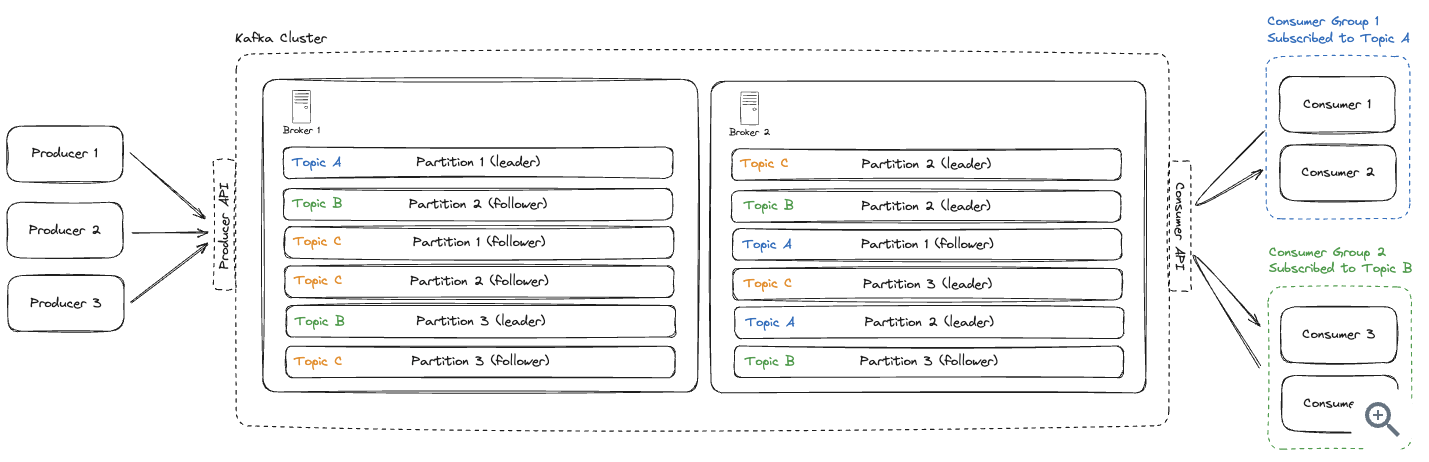